In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

import jax.numpy as jnp

# If trapezoid doesn’t exist, patch it
if not hasattr(jnp, "trapezoid") and hasattr(jnp, "trapz"):
    jnp.trapezoid = jnp.trapz

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

import hnoca.snapseed as snap
from hnoca.snapseed.utils import read_yaml
import hnoca.mapping as mapping

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
## Load Datasets ##

# Ref - HNOCA #
hnoca = sc.read_h5ad('/home/deepak/datasets/organoid_atlases/He_Treutlein_2024/bee26cec-e267-420d-aa27-5cbe80389d67.h5ad')
hnoca.layers['raw_counts'] = hnoca.raw.X
del hnoca.raw

# Query # 

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')

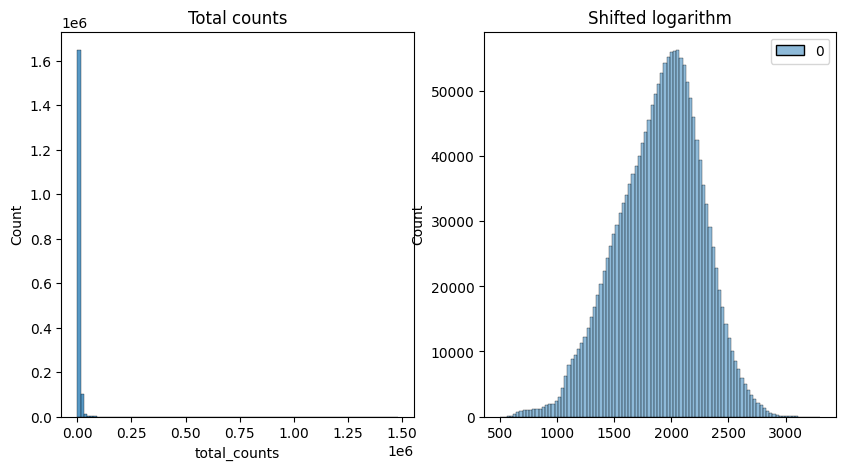

In [3]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(hnoca, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
hnoca.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
hnoca.X = hnoca.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(hnoca.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(hnoca.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [25]:
## HNOCA ##

# snapseed annotation #

# Read in the marker genes
marker_genes = read_yaml("/mnt/sdb/scz_meta_analysis_processed/models/hnoca_models/Data_S1_snapseed_markers.yaml")

# annotate multilevel hierarchies
adata.obs['hnoca_clusters'] = adata.obs['class'].astype('str')
results = snap.annotate_hierarchy(adata, marker_genes, group_name="hnoca_clusters", layer="log1p_norm")

In [29]:
results['assignments']

,level_1,level_2,level_3,level_4,level_5
hnoca_clusters,,,,,
1,neural_progenitor_cell,telencephalic_npc,NaN,NaN,NaN
2,neural_progenitor_cell,glioblast,NaN,NaN,NaN
3,neural_progenitor_cell,telencephalic_npc,ventral_npc,NaN,NaN
4,neural_progenitor_cell,glioblast,NaN,NaN,NaN
5,neuron,excitatory_neuron,NaN,NaN,NaN


In [ ]:
## Setup Model & Begin Training ##

scvi.model.SCVI.setup_anndata(hnoca, layer="raw_counts",     
                              batch_key='batch',
                              categorical_covariate_keys=["publication", 'donor_id', "sex"],
                              continuous_covariate_keys=["total_counts", "total_counts_mt"])

model = scvi.model.SCVI(hnoca, n_hidden=1024, n_latent=30, n_layers=4)

model.train(max_epochs=20, train_size=0.9, early_stopping=True, batch_size=2048)

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:186: UserWarning: Category 172 in adata.obs['_scvi_batch'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left plot: Train vs Validation ELBO ----
axes[0].plot(model.history["elbo_train"], label="Train ELBO")
axes[0].plot(model.history["elbo_validation"], label="Validation ELBO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_ylim(0, 1000)
axes[0].set_title("Train vs Validation ELBO")
axes[0].legend()

# ---- Right plot: Reconstruction vs KL ----
axes[1].plot(model.history["reconstruction_loss_validation"], label="Reconstruction (val)")
axes[1].plot(model.history["kl_local_validation"], label="KL (val)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Component")
axes[1].set_ylim(0, 1000)
axes[1].set_title("Reconstruction vs KL (Validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
# ## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# # ---- Left plot: Train vs Validation ELBO ----
# axes[0].plot(model.history["elbo_train"], label="Train ELBO")
# axes[0].plot(model.history["elbo_validation"], label="Validation ELBO")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("ELBO")
# axes[0].set_ylim(0, 1000)
# axes[0].set_title("Train vs Validation ELBO")
# axes[0].legend()

# # ---- Right plot: Reconstruction vs KL ----
# axes[1].plot(model.history["reconstruction_loss_validation"], label="Reconstruction (val)")
# axes[1].plot(model.history["kl_local_validation"], label="KL (val)")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("Loss Component")
# axes[1].set_ylim(0, 1000)
# axes[1].set_title("Reconstruction vs KL (Validation)")
# axes[1].legend()

# plt.tight_layout()
# plt.show()